'svm_optimization_enhanced.gif'

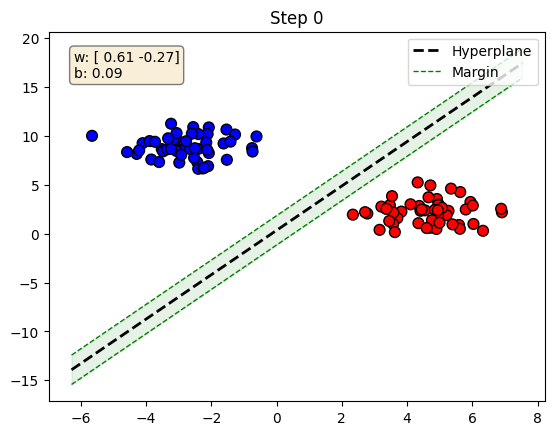

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.2)
y = np.where(y == 0, -1, 1)  # Convert labels to -1 and 1
lr = 0.01
lambda_ = 1
steps =200
w = np.random.randn(2)
b = 0
fig, ax = plt.subplots()
def plot_hyperplane(w, b, X, y, ax, step):
   ax.clear()
   ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', s=60)
   x_min, x_max = ax.get_xlim()
   x_vals = np.linspace(x_min, x_max, 100)
   y_vals = -(w[0] * x_vals + b) / w[1]
   ax.plot(x_vals, y_vals, 'k--', lw=2, label='Hyperplane')
   margin = 1 / np.linalg.norm(w)
   y_margin_up = y_vals + margin
   y_margin_down = y_vals - margin
   ax.plot(x_vals, y_margin_up, 'g--', lw=1, label='Margin')
   ax.plot(x_vals, y_margin_down, 'g--', lw=1)
   ax.fill_between(x_vals, y_margin_down, y_margin_up, color='green', alpha=0.1)
   ax.set_title(f"Step {step}")
   ax.text(0.05, 0.95, f"w: {np.round(w, 2)}\nb: {np.round(b, 2)}", transform=ax.transAxes,
           fontsize=10, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
   ax.legend(loc='upper right')
def hinge_loss(w, b, X, y):
   return np.maximum(0, 1 - y * (X @ w + b))
def objective(w, b, X, y, lambda_):
   return 0.5 * np.dot(w, w) + lambda_ * np.sum(hinge_loss(w, b, X, y))
def update(step):
   global w, b
   if step == 0:
       plot_hyperplane(w, b, X, y, ax, step)
       return
   loss = hinge_loss(w, b, X, y)
   mask = loss > 0
   dw = w - lambda_ * np.sum((y[mask, np.newaxis] * X[mask]), axis=0)
   db = -lambda_ * np.sum(y[mask])
   w -= lr * dw
   b -= lr * db
   plot_hyperplane(w, b, X, y, ax, step)
anim = FuncAnimation(fig, update, frames=steps, interval=100)
gif_path = "svm_optimization_enhanced.gif"
anim.save(gif_path, writer=PillowWriter(fps=10))
gif_path